In [1315]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from lib import spoti
import json
import os
from typing import List, Dict, Tuple
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import numpy as np

In [1316]:
DATA_PATH = os.path.join("data")

# Data users & cleaning

In [1317]:
owen = spoti.SpotiUser("owen")
brenda = spoti.SpotiUser("brenda")
arthur = spoti.SpotiUser("arthur")
michelle = spoti.SpotiUser("michelle")
paul = spoti.SpotiUser("paul")
jaslkh = spoti.SpotiUser("jaslkh")
lsirwguhu = spoti.SpotiUser("lsirwguhu")

In [1318]:
USERS = [jaslkh, owen, brenda, arthur, michelle, paul, lsirwguhu]

In [1319]:
def get_data_path(user: spoti.SpotiUser) -> str:
    return os.path.join(DATA_PATH, f"{user.username}_top_tracks.json")

In [1320]:
def simplify_genre(genres: List[str]) -> List[str]:
    for i, genre in enumerate(genres):
        if "rock" in genre: genres[i] = "rock"
        if "pop" in genre: genres[i] = "pop"
        if "rap" in genre: genres[i] = "rap"
        if "hip hop" in genre: genres[i] = "rap"
        if "emo" in genre or "punk" in genre or "screamo" in genre or "hardcore" in genre or "dreamo" in genre or "grunge" in genre: genres[i] = "emo/punk/grunge"
        if "metal" in genre: genres[i] = "metal"
        if "lo-fi" in genre or "chill" in genre or "lofi" in genre: genres[i] = "lo-fi"
        if "indie" in genre: genres[i] = "indie"
        if "french" in genre or "francophone" in genre or "francais" in genre: genres[i] = "french"
        if "house" in genre or "edm" in genre or "electro" in genre or "electronic" in genre: genres[i] = "electronic"
        if "jazz" in genre: genres[i] = "jazz"
        if "classical" in genre: genres[i] = "classical"
        if "r&b" in genre or "soul" in genre: genres[i] = "r&b"
    return list(set(genres))

USERS_DF = []
for user in USERS:
    df = pd.read_json(get_data_path(user), orient="records")
    df["simplified_genres"] = df["genres"].apply(simplify_genre)
    df["username"] = user.username
    USERS_DF.append(df)

df = pd.concat(USERS_DF)

In [1321]:
penality_factors = {
    "short_term": 1,
    "medium_term": 1,
    "long_term": 1
}

for user, df_sub_user in df.groupby("username"):
    for time_range, df_sub_user_time_range in df_sub_user.groupby("time_range"):
        # Add affinity column, to goes from 0 to 1, it's just a incremental index
        size = len(df_sub_user_time_range)
        penality_factor = penality_factors[time_range]
        df_sub_user_time_range["affinity"] = range(1, size + 1)[::-1]
        df.loc[df_sub_user_time_range.index, "affinity"] = (df_sub_user_time_range["affinity"] * penality_factor) / size

df = df.reset_index(drop=True)
df

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,type_features,uri_features,track_href,analysis_url,duration_ms_features,time_signature,time_range,simplified_genres,username,affinity
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,196426,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,audio_features,spotify:track:75rqqKvzJCGv2oq9C4yFDt,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,https://api.spotify.com/v1/audio-analysis/75rq...,196427,4,medium_term,"[r&b, pop]",jaslkh,1.00
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,137533,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,audio_features,spotify:track:2FYGZDfsAnNsrm1gVbyKnG,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,https://api.spotify.com/v1/audio-analysis/2FYG...,137533,4,medium_term,"[r&b, pop]",jaslkh,0.98
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,162906,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,audio_features,spotify:track:4kroNlz8BTfswE4M0i3YCh,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,https://api.spotify.com/v1/audio-analysis/4kro...,162907,3,medium_term,"[r&b, pop]",jaslkh,0.96
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,89749,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,audio_features,spotify:track:2N3YZ075lq9z1ObaAiX6l1,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,https://api.spotify.com/v1/audio-analysis/2N3Y...,89749,4,medium_term,"[r&b, pop]",jaslkh,0.94
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,174044,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,audio_features,spotify:track:2SiAcexM2p1yX6joESbehd,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,https://api.spotify.com/v1/audio-analysis/2SiA...,174045,4,medium_term,"[r&b, pop]",jaslkh,0.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,227093,False,{'isrc': 'QM24S2004459'},{'spotify': 'https://open.spotify.com/track/4A...,https://api.spotify.com/v1/tracks/4AssfJK5W9zn...,4AssfJK5W9zn2N1qdmeARM,...,audio_features,spotify:track:4AssfJK5W9zn2N1qdmeARM,https://api.spotify.com/v1/tracks/4AssfJK5W9zn...,https://api.spotify.com/v1/audio-analysis/4Ass...,227094,4,long_term,"[pop, r&b]",lsirwguhu,0.10
1046,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,134482,True,{'isrc': 'USAT22100334'},{'spotify': 'https://open.spotify.com/track/4K...,https://api.spotify.com/v1/tracks/4Kh6cq3XgOGU...,4Kh6cq3XgOGUK9yXQu7RTq,...,audio_features,spotify:track:4Kh6cq3XgOGUK9yXQu7RTq,https://api.spotify.com/v1/tracks/4Kh6cq3XgOGU...,https://api.spotify.com/v1/audio-analysis/4Kh6...,134483,4,long_term,"[alt z, pop, electronic]",lsirwguhu,0.08
1047,"{'a

# Analysis on the users

In [1322]:
px.pie(df, names="username", title="Number of Liked Tracks per User")

In [1323]:
def count_list_column_per_user(df: pd.DataFrame, column: str) -> pd.DataFrame:
    df_count = df.explode(column)
    df_count = df_count.groupby([column, "username"]).count().reset_index()
    df_count = df_count.rename(columns={"id": "count"})
    df_count = df_count[[column, "username", "count"]]
    df_count["count"] = df_count["count"] / df_count.groupby("username")["count"].transform("sum")
    df_count = df_count.sort_values("count", ascending=False)
    return df_count

In [1324]:
# Turn dataset into a list of genres
df_count_genre = count_list_column_per_user(df, "simplified_genres")
px.bar(df_count_genre.groupby("username").head(20), x="simplified_genres", y="count", color="username", title="Number of Liked Tracks per Genre", barmode="group")

In [1325]:
df["artists_names"] = df["artists"].apply(lambda x: [artist["name"] for artist in x])
df_count_artists = count_list_column_per_user(df, "artists_names")
px.bar(df_count_artists.groupby("username").head(100), x="artists_names", y="count", color="username", title="Number of liked artists per user", barmode="group")

In [1326]:
user_top_likes = owen
time_ranges = ["short_term", "medium_term", "long_term"]

top_tracks = df[(df["username"] == user_top_likes.username) & (df["time_range"].isin(time_ranges))] \
    .sort_values("popularity", ascending=False) \
    .sort_values("time_range", ascending=False) \
    .apply(lambda x: f"{x['artists'][0]['name']} - {x['name']} ({x['time_range']})", axis=1) \
    .to_list()

# print("\n".join(top_tracks))

In [1327]:
numeric_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "loudness",
    "duration_ms",
]

In [1328]:
def plot_latent_space(df: pd.DataFrame, hue: str = "username") -> None:
    """
    The latent space is the space where we will project our data, it is the space where we will be able to see the similarities between
    data points. To make it simple, if two data points are close in the latent space, it means that they are similar.
    :param df: dataframe containing the latent space (columns: latent_0, latent_1, ...)
    :return: None
    """
    dim = len(df.columns)
    if dim == 2:
        # Plot 2D latent space
        fig = go.Figure(data=go.Scatter(
            x=df["latent_0"],
            y=df["latent_1"],
            mode="markers+text",
            text=df.index,
            textposition="bottom center",
            marker=dict(
                size=10,
                # random color for each user
                color=df.index.map(lambda x: hash(x) % 100),
                colorscale="Bluered",
                showscale=False
            )
        ))
        # Set title
        fig.update_layout(title_text=f"Latent Space ({dim}D)")
        return fig
    elif dim == 3:
        # Plot 3D latent space
        fig = px.scatter_3d(df, x="latent_0", y="latent_1", z="latent_2", color=df.index, text=df.index)
        fig.update_traces(textposition="top center")
        fig.update_layout(
            margin=dict(l=0, r=0, b=0, t=0),
            scene = dict(
                xaxis_title="latent_0",
                yaxis_title="latent_1",
                zaxis_title="latent_2"
            )
        )
        # Set title
        fig.update_layout(title_text=f"Latent Space ({dim}D)")
        return fig
    else:
        # Pairplot
        df_plot = df.reset_index()
        fig = px.scatter_matrix(df_plot, dimensions=df_plot.columns, color=hue)
        # Set title
        fig.update_layout(title_text=f"Latent Space ({dim}D)")
        return fig

# Neural network latent space analysis

## Prepare data

### If we wanted to let the model choose the features by itself from the raw data

In [1329]:
# Scale the numeric features of df
from sklearn.preprocessing import MinMaxScaler
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_features] = scaler.fit_transform(df_scaled[numeric_features])
df_scaled

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,type_features,uri_features,track_href,analysis_url,duration_ms_features,time_signature,time_range,simplified_genres,username,affinity
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-0.173125,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,audio_features,spotify:track:75rqqKvzJCGv2oq9C4yFDt,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,https://api.spotify.com/v1/audio-analysis/75rq...,196427,4,medium_term,"[r&b, pop]",jaslkh,1.00
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-1.205273,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,audio_features,spotify:track:2FYGZDfsAnNsrm1gVbyKnG,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,https://api.spotify.com/v1/audio-analysis/2FYG...,137533,4,medium_term,"[r&b, pop]",jaslkh,0.98
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-0.760591,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,audio_features,spotify:track:4kroNlz8BTfswE4M0i3YCh,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,https://api.spotify.com/v1/audio-analysis/4kro...,162907,3,medium_term,"[r&b, pop]",jaslkh,0.96
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-2.042728,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,audio_features,spotify:track:2N3YZ075lq9z1ObaAiX6l1,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,https://api.spotify.com/v1/audio-analysis/2N3Y...,89749,4,medium_term,"[r&b, pop]",jaslkh,0.94
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-0.565388,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,audio_features,spotify:track:2SiAcexM2p1yX6joESbehd,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,https://api.spotify.com/v1/audio-analysis/2SiA...,174045,4,medium_term,"[r&b, pop]",jaslkh,0.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,0.364340,False,{'isrc': 'QM24S2004459'},{'spotify': 'https://open.spotify.com/track/4A...,https://api.spotify.com/v1/tracks/4AssfJK5W9zn...,4AssfJK5W9zn2N1qdmeARM,...,audio_features,spotify:track:4AssfJK5W9zn2N1qdmeARM,https://api.spotify.com/v1/tracks/4AssfJK5W9zn...,https://api.spotify.com/v1/audio-analysis/4Ass...,227094,4,long_term,"[pop, r&b]",lsirwguhu,0.10
1046,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-1.258745,True,{'isrc': 'USAT22100334'},{'spotify': 'https://open.spotify.com/track/4K...,https://api.spotify.com/v1/tracks/4Kh6cq3XgOGU...,4Kh6cq3XgOGUK9yXQu7RTq,...,audio_features,spotify:track:4Kh6cq3XgOGUK9yXQu7RTq,https://api.spotify.com/v1/tracks/4Kh6cq3XgOGU...,https://api.spotify.com/v1/audio-analysis/4Kh6...,134483,4,long_term,"[alt z, pop, electronic]",lsi

<Figure size 2000x1000 with 0 Axes>

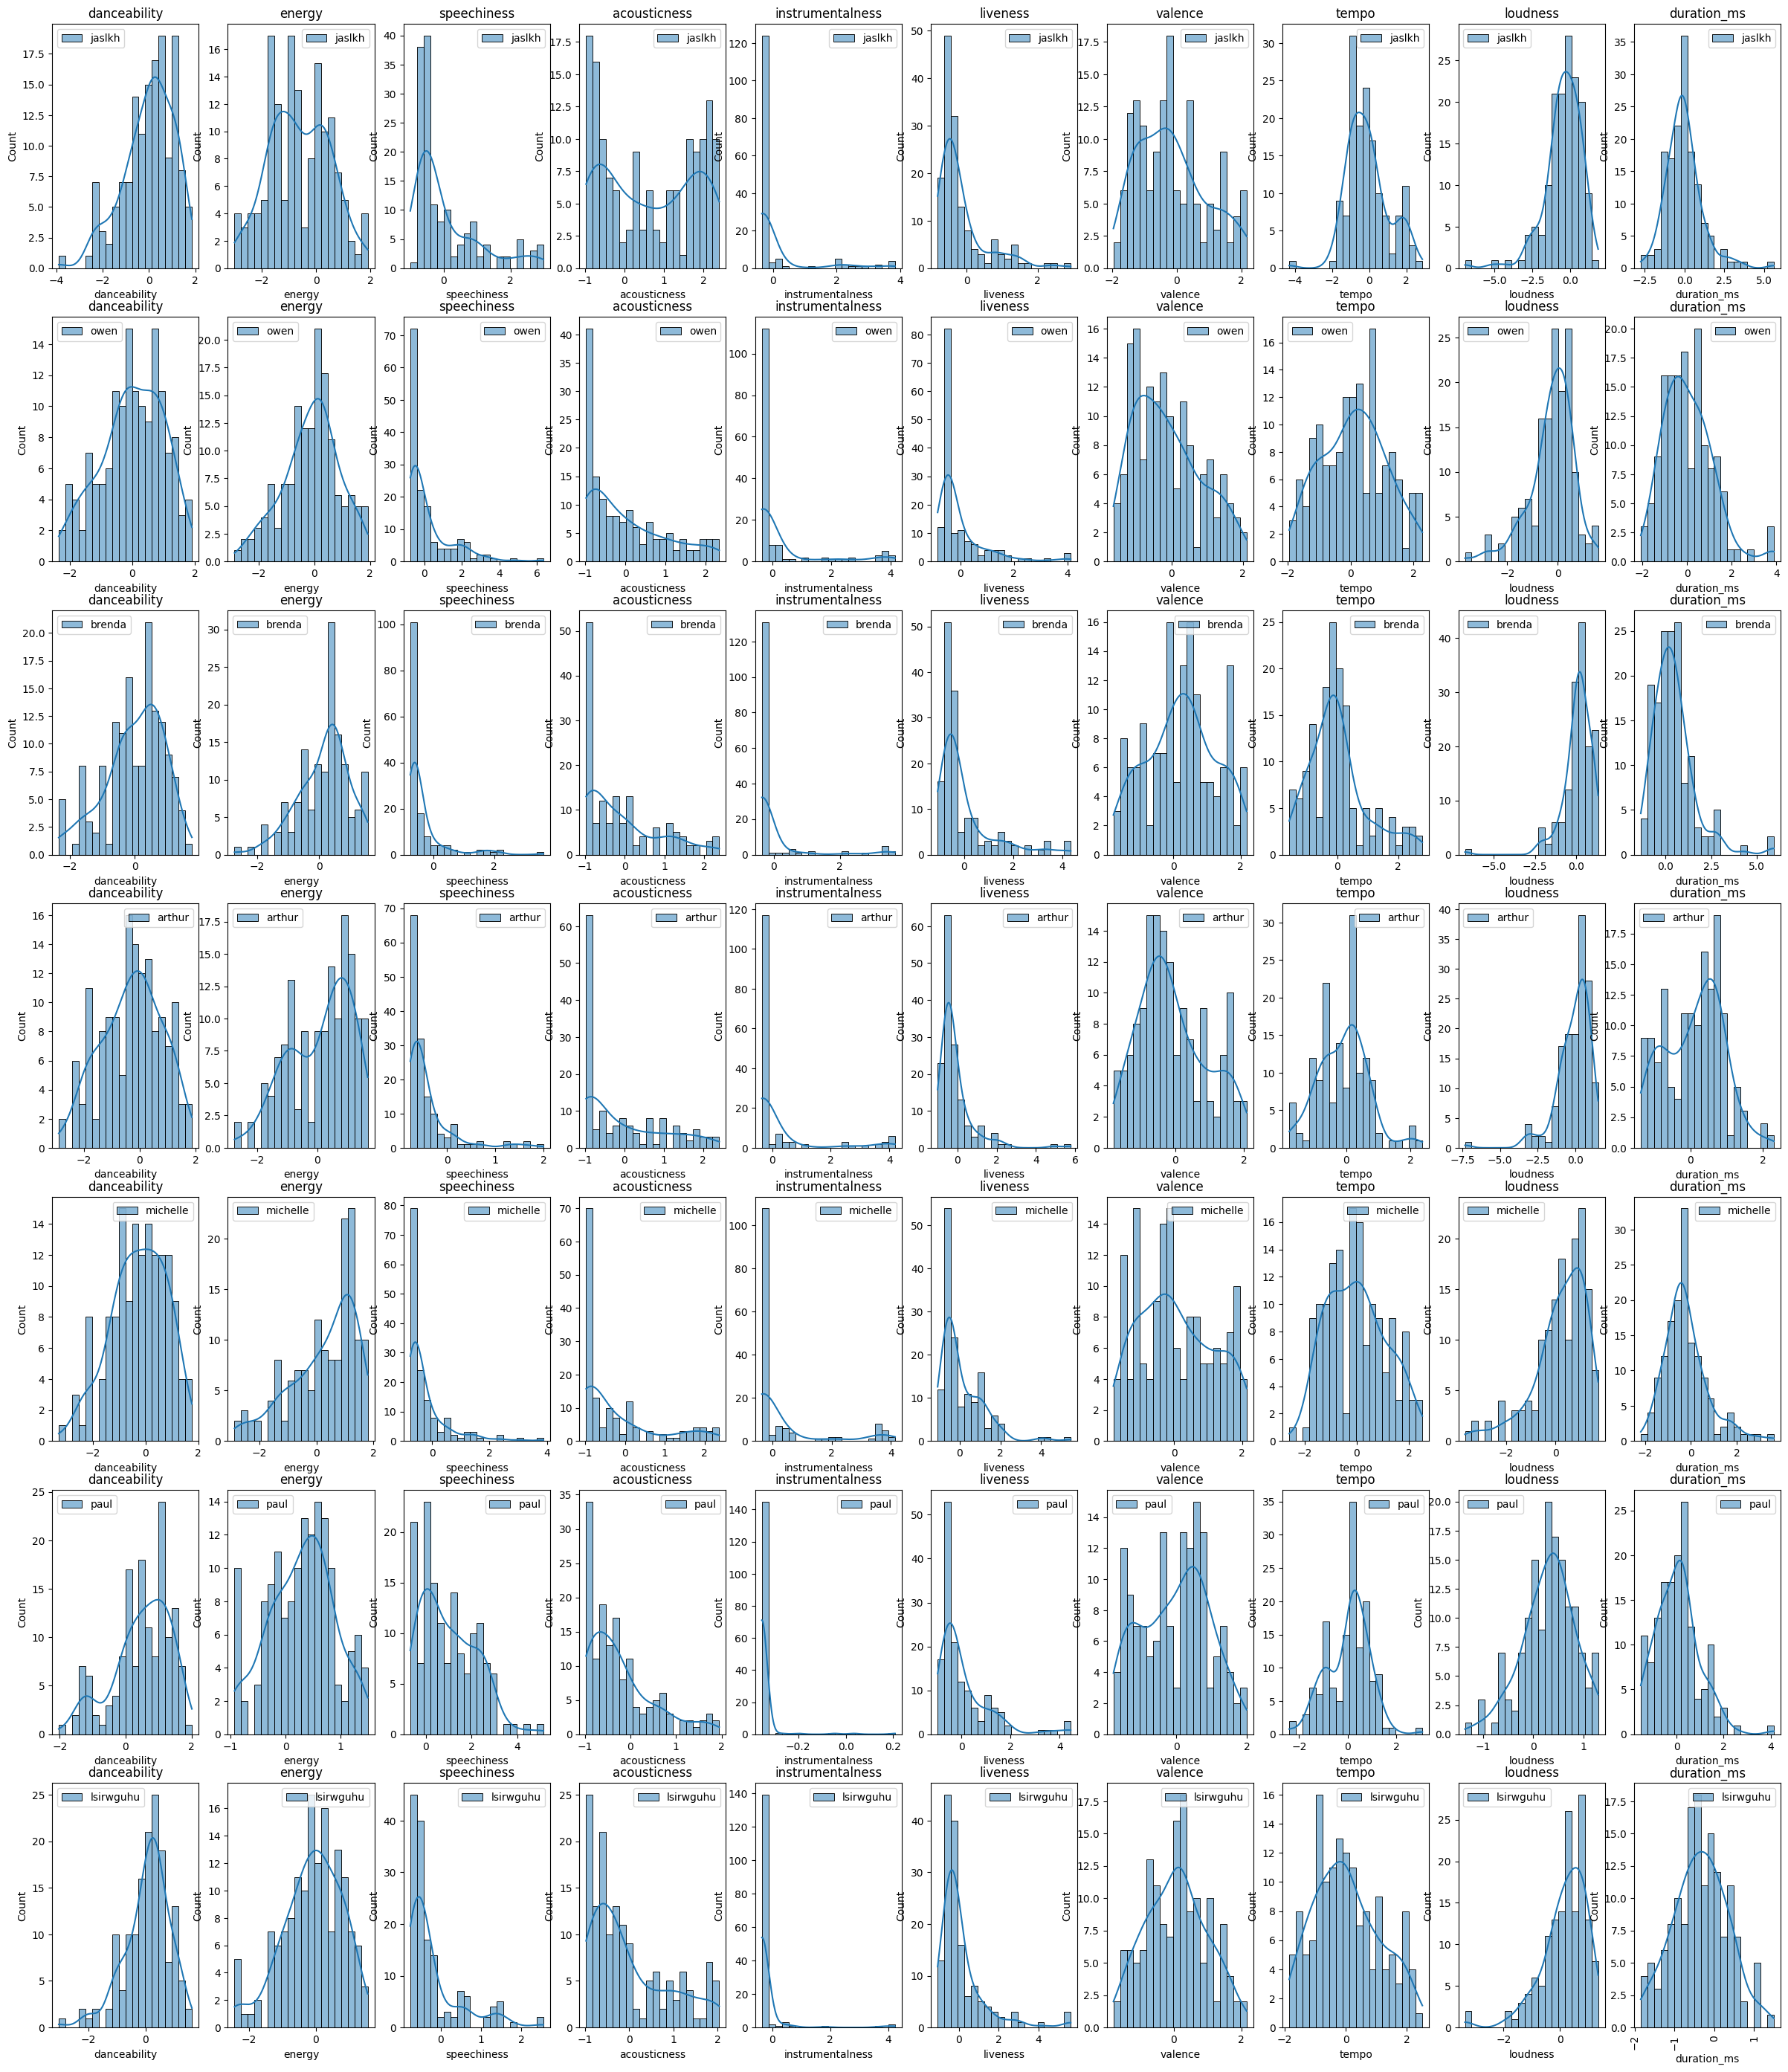

In [1330]:
plt.figure(figsize=(20,10))

fig, axs = plt.subplots(len(USERS), len(numeric_features), figsize=(30, len(USERS)*5))

for i, user in enumerate(USERS):
    # Show features distribution for each user
    user_top_tracks = df_scaled[df_scaled["username"] == user.username]
    for i, feature in enumerate(numeric_features):
        sns.histplot(x=feature, data=user_top_tracks, ax=axs[USERS.index(user), i], bins=20, kde=True, label=user.username)
        axs[USERS.index(user), i].set_title(feature)
        axs[USERS.index(user), i].legend()

plt.legend()
plt.xticks(rotation=90)
plt.show()

We need one row per user, let's extract:
- mean
- median
- std
- min
- max

In [1331]:
def q50(x):
    return x.quantile(0.5)

def q25(x):
    return x.quantile(0.25)

def q75(x):
    return x.quantile(0.75)

df_features_user = df_scaled.groupby("username")[numeric_features].agg(["median", q25, q50, q75]).reset_index()
df_features_user.columns = ["username"] + [f"{col}_{agg}" for col, agg in df_features_user.columns[1:]]
df_features_user.set_index("username", inplace=True)

user_features = list(df_features_user.columns)
df_features_user

,danceability_median,danceability_q25,danceability_q50,danceability_q75,energy_median,energy_q25,energy_q50,energy_q75,speechiness_median,speechiness_q25,...,tempo_q50,tempo_q75,loudness_median,loudness_q25,loudness_q50,loudness_q75,duration_ms_median,duration_ms_q25,duration_ms_q50,duration_ms_q75
username,,,,,,,,,,,,,,,,,,,,,
arthur,-0.254399,-1.087646,-0.254399,0.461359,0.383459,-0.803647,0.383459,0.916420,-0.599382,-0.673136,...,-0.019089,0.303880,0.229722,-0.671735,0.229722,0.677512,0.194690,-0.648973,0.194690,0.695701
brenda,0.181549,-0.507929,0.181549,0.671603,0.333996,-0.407945,0.333996,0.680235,-0.603808,-0.684690,...,-0.140687,0.305766,0.223623,-0.227887,0.223623,0.666206,0.287594,-0.268404,0.287594,0.755744
jaslkh,0.147538,-0.670250,0.147538,0.830832,-0.724507,-1.508491,-0.724507,0.249909,-0.447451,-0.610937,...,-0.192386,0.461459,-0.308221,-0.954691,-0.308221,0.390763,-0.145092,-0.760187,-0.145092,0.439574
lsirwguhu,0.162998,-0.319327,0.162998,0.524741,-0.024609,-0.620635,-0.024609,0.629536,-0.483344,-0.626179,...,-0.071873,0.809788,0.311247,-0.195456,0.311247,0.769153,-0.350872,-0.789797,-0.350872,0.110338
michelle,-0.204930,-0.934601,-0.204930,0.585032,0.601095,-0.431440,0.601095,1.140238,-0.559064,-0.668465,...,-0.053229,0.732533,0.381614,-0.218663,0.381614,1.035447,-0.383890,-0.759609,-0.383890,0.203089
owen,0.033141,-0.600684,0.033141,0.764358,0.037220,-0.698539,0.037220,0.492277,-0.381073,-0.634784,...,0.110568,0.793697,-0.062160,-0.560010,-0.062160,0.349852,-0.141421,-0.758562,-0.141421,0.647435
paul,0.574210,0.023865,0.574210,1.147744,0.348835,-0.126007,0.348835,0.704966,0.755218,-0.009357,...,0.163762,0.647699,0.333562,0.004488,0.333562,0.654528,0.034442,-0.628209,0.034442,0.468619


In [1332]:
df_tracks_user_merged = df_scaled.join(df_features_user, on="username", how="inner")
df_tracks_user_merged

,album,artists,available_markets,disc_number,duration_ms,explicit,external_ids,external_urls,href,id,...,tempo_q50,tempo_q75,loudness_median,loudness_q25,loudness_q50,loudness_q75,duration_ms_median,duration_ms_q25,duration_ms_q50,duration_ms_q75
0,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-0.173125,False,{'isrc': 'USSM12301260'},{'spotify': 'https://open.spotify.com/track/75...,https://api.spotify.com/v1/tracks/75rqqKvzJCGv...,75rqqKvzJCGv2oq9C4yFDt,...,-0.192386,0.461459,-0.308221,-0.954691,-0.308221,0.390763,-0.145092,-0.760187,-0.145092,0.439574
1,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-1.205273,True,{'isrc': 'USSM12109218'},{'spotify': 'https://open.spotify.com/track/2F...,https://api.spotify.com/v1/tracks/2FYGZDfsAnNs...,2FYGZDfsAnNsrm1gVbyKnG,...,-0.192386,0.461459,-0.308221,-0.954691,-0.308221,0.390763,-0.145092,-0.760187,-0.145092,0.439574
2,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-0.760591,True,{'isrc': 'USSM12109222'},{'spotify': 'https://open.spotify.com/track/4k...,https://api.spotify.com/v1/tracks/4kroNlz8BTfs...,4kroNlz8BTfswE4M0i3YCh,...,-0.192386,0.461459,-0.308221,-0.954691,-0.308221,0.390763,-0.145092,-0.760187,-0.145092,0.439574
3,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-2.042728,False,{'isrc': 'USSM12208854'},{'spotify': 'https://open.spotify.com/track/2N...,https://api.spotify.com/v1/tracks/2N3YZ075lq9z...,2N3YZ075lq9z1ObaAiX6l1,...,-0.192386,0.461459,-0.308221,-0.954691,-0.308221,0.390763,-0.145092,-0.760187,-0.145092,0.439574
4,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-0.565388,False,{'isrc': 'USSM12300114'},{'spotify': 'https://open.spotify.com/track/2S...,https://api.spotify.com/v1/tracks/2SiAcexM2p1y...,2SiAcexM2p1yX6joESbehd,...,-0.192386,0.461459,-0.308221,-0.954691,-0.308221,0.390763,-0.145092,-0.760187,-0.145092,0.439574
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,0.364340,False,{'isrc': 'QM24S2004459'},{'spotify': 'https://open.spotify.com/track/4A...,https://api.spotify.com/v1/tracks/4AssfJK5W9zn...,4AssfJK5W9zn2N1qdmeARM,...,-0.071873,0.809788,0.311247,-0.195456,0.311247,0.769153,-0.350872,-0.789797,-0.350872,0.110338
1046,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-1.258745,True,{'isrc': 'USAT22100334'},{'spotify': 'https://open.spotify.com/track/4K...,https://api.spotify.com/v1/tracks/4Kh6cq3XgOGU...,4Kh6cq3XgOGUK9yXQu7RTq,...,-0.071873,0.809788,0.311247,-0.195456,0.311247,0.769153,-0.350872,-0.789797,-0.350872,0.110338
1047,"{'album_type': 'SINGLE', 'artists': [{'externa...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-0.552138,False,{'isrc': 'QZ93L1916299'},{'spotify': 'https://open.spotify.com/track/06...,https://api.spotify.com/v1/tracks/06moNojepTMS...,06moNojepTMSDnlzyD2k52,...,-0.071873,0.809788,0.311247,-0.195456,0.311247,0.769153,-0.350872,-0.789797,-0.350872,0.110338
1048,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,0.043495,False,{'isrc': 'USAT21700928'},{'spotify': 'https://open.spotify.com/track/5c...,https://api.spotify.com/v1/trac

## Define the model

In [1333]:
user_features_dim = len(user_features)
music_features_dim = len(numeric_features)
latent_size = 3

print(f"User features dim: {user_features_dim}")
print(f"Music features dim: {music_features_dim}")
print(f"Latent size: {latent_size}")

User features dim: 40
Music features dim: 10
Latent size: 3


In [1334]:
class DualInputAutoencoder(nn.Module):
    def __init__(self, user_features, music_features, latent_size):
        super(DualInputAutoencoder, self).__init__()
        
        # Encoder for the users
        self.user_encoder = nn.Sequential(
            nn.Linear(user_features, 64),
            nn.ReLU(True),
            nn.Linear(64, 64),
            nn.ReLU(True),
            nn.Linear(64, latent_size),
        )
        
        # Encoder for the tracks
        self.music_encoder = nn.Sequential(
            nn.Linear(music_features, 64),
            nn.ReLU(True),
            nn.Linear(64, 64),
            nn.ReLU(True),
            nn.Linear(64, latent_size),
        )
        
        # Decoder for both inputs
        self.decoder = nn.Sequential(
            nn.Linear(latent_size * 2, 64),
            nn.ReLU(True),
            nn.Linear(64, 64),
            nn.ReLU(True),
            nn.Linear(64, user_features + music_features),  # Reconstuction of both inputs
            nn.Tanh()
        )

    def forward(self, user_data, music_data):
        user_latent = self.user_encoder(user_data)
        music_latent = self.music_encoder(music_data)

        # Concatenate the two latent spaces
        combined_latent = torch.cat((user_latent, music_latent), dim=1)

        # Reconstruction
        reconstruction = self.decoder(combined_latent)
        return reconstruction, user_latent, music_latent

In [1335]:
## Create the autoencoder
model = DualInputAutoencoder(user_features_dim, music_features_dim, latent_size)

# Choice of loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [1336]:
user_data = torch.tensor(df_tracks_user_merged[user_features].values, dtype=torch.float)
music_data = torch.tensor(df_tracks_user_merged[numeric_features].values, dtype=torch.float)

# Make data loader
data_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(user_data, music_data),
    batch_size=32,
    shuffle=True
)

print(user_data.shape, music_data.shape)

torch.Size([1050, 40]) torch.Size([1050, 10])


In [1337]:
num_epochs = 300
losses = []
for epoch in range(num_epochs + 1):
    for user_data, music_data in data_loader:
        # Forward pass
        outputs, _, _ = model(user_data, music_data)
        loss = criterion(outputs, torch.cat((user_data, music_data), dim=1))

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    losses.append(loss.item())
    print(f"Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}")

Epoch [0/300], Loss: 0.3241
Epoch [1/300], Loss: 0.2544
Epoch [2/300], Loss: 0.2027
Epoch [3/300], Loss: 0.1403
Epoch [4/300], Loss: 0.0926
Epoch [5/300], Loss: 0.1223
Epoch [6/300], Loss: 0.1067
Epoch [7/300], Loss: 0.1553
Epoch [8/300], Loss: 0.1093
Epoch [9/300], Loss: 0.0904
Epoch [10/300], Loss: 0.1523
Epoch [11/300], Loss: 0.0874
Epoch [12/300], Loss: 0.1060
Epoch [13/300], Loss: 0.1207
Epoch [14/300], Loss: 0.1387
Epoch [15/300], Loss: 0.0715
Epoch [16/300], Loss: 0.1150
Epoch [17/300], Loss: 0.1084
Epoch [18/300], Loss: 0.0705
Epoch [19/300], Loss: 0.1101
Epoch [20/300], Loss: 0.0951
Epoch [21/300], Loss: 0.1165
Epoch [22/300], Loss: 0.0895
Epoch [23/300], Loss: 0.0858
Epoch [24/300], Loss: 0.1071
Epoch [25/300], Loss: 0.1364
Epoch [26/300], Loss: 0.1022
Epoch [27/300], Loss: 0.0701
Epoch [28/300], Loss: 0.0874
Epoch [29/300], Loss: 0.1565
Epoch [30/300], Loss: 0.1498
Epoch [31/300], Loss: 0.0884
Epoch [32/300], Loss: 0.0671
Epoch [33/300], Loss: 0.1703
Epoch [34/300], Loss: 0.

In [1338]:
# Plot loss
px.line(x=range(len(losses)), y=losses, title="Loss")

In [1339]:
# extract the user encoder
user_encoder = model.user_encoder
user_encoder.eval()

user_tensor = torch.tensor(df_features_user.values, dtype=torch.float)

# project users into latent space
user_latent = user_encoder(user_tensor).detach().numpy()
df_user_latent = pd.DataFrame(user_latent, columns=[f"latent_{i}" for i in range(latent_size)], index=df_features_user.index)
df_user_latent

if latent_size <= 3:
    plot_latent_space(df_user_latent).show()

In [1340]:
# extract the music encoder
music_encoder = model.music_encoder
music_encoder.eval()

music_tensor = torch.tensor(df_scaled[numeric_features].values, dtype=torch.float)

# project musics into latent space
music_latent = music_encoder(music_tensor).detach().numpy()

# From df_scaled to df_music_latent
df_music_latent = pd.DataFrame(music_latent, columns=[f"latent_{i}" for i in range(latent_size)], index=df_scaled.index)

# Add username column
df_music_latent["username"] = df_scaled["username"]
df_music_latent.set_index("username", inplace=True)

if latent_size <= 3:
    fig = plot_latent_space(df_music_latent)
    for i, user in enumerate(user_latent):
        fig.add_trace(go.Scatter3d(
            x=[user[0]],
            y=[user[1]],
            z=[user[2]],
            mode="markers+text",
            text=df_user_latent.index[i],
            textposition="bottom center",
            marker=dict(
                size=10,
                # random color for each user
                color=i,
                colorscale="Bluered",
                showscale=False
            ),
            name=f"{df_user_latent.index[i]} (user)"
        ))
    fig.show()

In [1341]:
from sklearn.metrics.pairwise import cosine_similarity
def make_recommendations(user_latent: np.ndarray, tracks_latent: np.ndarray, df_tracks: pd.DataFrame, top_n: int = -1) -> np.ndarray:
    """
    Make recommendations for a given user
    :param user_latent: user latent space
    :param tracks_latent: N music latent spaces (N, latent_size)
    :param df_tracks: dataframe containing the tracks
    :param top_n: number of recommendations to return
    :return: indices of recommended tracks
    """
    if top_n == -1:
        top_n = len(tracks_latent)
    
    # Compute cosine similarity between user and tracks
    similarities = cosine_similarity(user_latent.reshape(1, -1), tracks_latent)[0]
    # Get top N similar tracks
    top_n_indices = np.argsort(similarities)[::-1][:top_n]
    # Return top N tracks
    return df_tracks.iloc[top_n_indices]

In [1342]:
df_all = pd.read_json(os.path.join(DATA_PATH, "tracks.json"), orient="records")
df_all

# Project all tracks into latent space
df_all_scaled = df_all.copy()
df_all_scaled[numeric_features] = scaler.transform(df_all_scaled[numeric_features])
df_all_scaled

# Project all tracks into latent space
df_all_scaled_tensor = torch.tensor(df_all_scaled[numeric_features].values, dtype=torch.float)
df_all_latent = music_encoder(df_all_scaled_tensor).detach().numpy()
df_all_latent = pd.DataFrame(df_all_latent, columns=[f"latent_{i}" for i in range(latent_size)], index=df_all_scaled.index)

# Add username column
df_all_latent["username"] = "all_songs"
df_all_latent.set_index("username", inplace=True)

In [1347]:
# pick a random user from unique users
user = np.random.choice(df["username"].unique())

user = "arthur"
# Get user features
user_features = df_features_user.loc[user]
# Get user latent space
user_latent = user_encoder(torch.tensor(user_features.values, dtype=torch.float)).detach().numpy()
print(f"User: {user} - User latent space: {user_latent}")

# pick N random tracks from the dataset
N = len(df_scaled)
tracks = df_scaled.sample(N)

# Get tracks features
tracks_features = tracks[numeric_features]
# Get tracks latent space
tracks_latent = music_encoder(torch.tensor(tracks_features.values, dtype=torch.float)).detach().numpy()
df_tracks_latent = pd.DataFrame(tracks_latent, columns=[f"latent_{i}" for i in range(latent_size)], index=tracks.index)
df_tracks_latent["username"] = tracks["username"]
df_tracks_latent.set_index("username", inplace=True)

if latent_size <= 3:
    fig = plot_latent_space(df_tracks_latent)
    fig.add_trace(go.Scatter3d(
        x=[user_latent[0]],
        y=[user_latent[1]],
        z=[user_latent[2]],
        mode="markers+text",
        text=[user],
        textposition="bottom center",
        marker=dict(
            size=10,
            color="red",
            showscale=False
        ),
        name=f"{user} (user)"
    ))
    fig.show()

# print the tracks
# for i, track in tracks.iterrows():
#     print(f"{track['username']}: {track['artists_names'][0]} - {track['name']}")

make_recommendations(user_latent, tracks_latent, df_tracks=tracks)[["name_artists", "name", "username"]]

User: arthur - User latent space: [ 0.258171 -6.566972 -0.333774]


,name_artists,name,username
33,Charlotte Adigéry,Ceci n'est pas un cliché,jaslkh
533,Angèle,Démons,arthur
836,Angèle,Démons,paul
742,DEAN,instagram,michelle
350,Clean Bandit,Rather Be (feat. Jess Glynne),brenda
...,...,...,...
798,CJ,Whoopty,paul
848,CJ,Whoopty,paul
888,CJ,Whoopty,paul
1010,Dream,Change My Clothes,lsirwguhu


In [1344]:
class VAEMatrix:
    @property
    def matrix(self):
        return self._vae_matrix

    def __init__(self, df: pd.DataFrame):
        self._df = df
        self._usernames = df["username"].unique().tolist()
        self._tracks = df["id"].to_list()
        self.reset_matrix()

    def build_matrix(self):
        # Build matrix
        # Put 1 if the user liked the track
        for i, user in enumerate(self._usernames):
            for j, track in enumerate(self._tracks):
                if len(self._df[(self._df["username"] == user) & (self._df["id"] == track)]) > 0:
                    self._vae_matrix[i, j] = 1
    
    def insert_features(self, df_features: pd.DataFrame, columns: List[str] = []):
        new_matrix = np.zeros((len(self._usernames), len(self._tracks), len(columns)))
        for i, user in enumerate(self._usernames):
            for j, track in enumerate(self._tracks):
                if self._vae_matrix[i, j] == 1:
                    values = self.retrieve_row(i, j, df_features)
                    new_matrix[i, j] = values[columns].to_numpy()
        return new_matrix
    
    def reset_matrix(self):
        self._vae_matrix = np.zeros((len(self._usernames), len(self._tracks)))
    
    def retrieve_row(self, user_index: int, track_index: int, df_mapping: pd.DataFrame = None) -> pd.Series:
        username = self._usernames[user_index]
        track = self._tracks[track_index]
        return df_mapping[(df_mapping["username"] == username) & (df_mapping["id"] == track)].iloc[0]
    
    def to_string(self, df_mapping: pd.DataFrame = None, columns: List[str] = []) -> str:
        if df_mapping is None:
            df_mapping = self._df
        s = ""
        for i in range(0, len(self._vae_matrix)):
            for j in range(0, len(self._vae_matrix[i])):
                if self._vae_matrix[i, j] == 1:
                    values = self.retrieve_row(i, j, df_mapping)
                    s += ", ".join([f"{col}: {values[col]}" for col in columns]) + "\n"
        return s.strip()